# Retrieval

In [1]:
import numpy as np # Used for return type and embeddings .
import open_clip # Used to load image embedding model  .
import torch # Used for device handling and tensor operations .
import os # Used for locating database storage .
from sentence_transformers import SentenceTransformer # Used to load text embedding model .
import chromadb # Used for vectorDB operations .
from typing import Dict # Used for datatype handling .
from dotenv import load_dotenv # Used for loading Huggingface api .
import os

In [2]:
load_dotenv() # For loading Huggingface api .

True

In [3]:
# Removing unwanted warnings from sentence transformers library .(Optional)
import warnings
from transformers import logging

logging.set_verbosity_error()
warnings.filterwarnings("ignore", message=".*position_ids.*UNEXPECTED.*")

In [4]:
# Used image embedding and query embedding .
class OpenClipTextEmbeddingModel:
     def __init__(self, model_name: str = "ViT-L-14", pretrained: str = "laion2b_s32b_b82k"):

        self.device="cuda" if torch.cuda.is_available() else "cpu" # Used to check if the machine has GPU if not assign CPU as device for working .
        self.model,self.preprocess,_=open_clip.create_model_and_transforms(
            model_name=model_name,
            pretrained=pretrained
        ) # Getting essential function from model .
        self.tokenizer=open_clip.get_tokenizer(model_name)
        self.model=self.model.to(self.device) # Device selection for model operations .
        self.model.eval() # Loading model

        # Displaying device on which model will run .
        if self.device=="cuda":
            print(f"OpenClip running on {torch.cuda.get_device_name(0)} .")
        else:
            print("OpenClip running on CPU .")
        print(f"Embedding dimensions of {model_name} is {open_clip.get_model_config(model_name).get('embed_dim')}")

     @torch.no_grad()
     def embed_query(self,query:str)->np.ndarray:
         if not query.strip():
             raise ValueError("Please give a valid prompt .")

         tokens=self.tokenizer([query]).to(self.device) # Used to convert into tensor .
         query_embedding=self.model.encode_text(tokens) # Embedding text or tensor value .
         query_embedding=query_embedding/query_embedding.norm(dim=-1,keepdim=True) # Normalizing values
         query_embedding=query_embedding.cpu().numpy()[0] # Converting tensor to numpy array .

         return query_embedding # Returning all the embeddings .

In [5]:
image_model=OpenClipTextEmbeddingModel()

OpenClip running on CPU .
Embedding dimensions of ViT-L-14 is 768


In [6]:
# Used for text embedding and query embedding .
class BGETextEmbeddingModel:

    def __init__(self, model_name: str = "BAAI/bge-large-en-v1.5"):
        self.device="cuda" if torch.cuda.is_available() else "cpu" # Device check .
        self.model=SentenceTransformer(model_name_or_path=model_name,device=self.device) # Loading model .
        self.query_prefix="Represent this sentence for searching relevant passages: "
        if self.device=="cuda":
            print(f"BGE running on {torch.cuda.get_device_name(0)} .")
        else:
            print("BGE running on CPU .")
        print(f"Dimension of {model_name} is {self.model.get_sentence_embedding_dimension()}")

    @torch.no_grad()
    def embed_query(self,query:str)->np.ndarray:

        if not query.strip():
            raise ValueError("Given prompt is not valid .")

        query=self.query_prefix + query # Adding a prefix to prompt since BGE is instruction based embedding model .(Only for prompt not mandatory for documents)

        query_embedding=self.model.encode( # Embedding query .
            sentences=query,
            normalize_embeddings=True,
            convert_to_numpy=True
        )

        return query_embedding # Returning embedded values .

In [7]:
text_model=BGETextEmbeddingModel()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BGE running on CPU .
Dimension of BAAI/bge-large-en-v1.5 is 1024


In [8]:
class VectorStore:
    def __init__(self,collection_name:str,directory:str="../data/database"):
        self.collection_name=collection_name # Collection name .
        self.persistent_directory=directory # Directory to store database .
        self.collection=None # Collection , used to store data .
        self.client=None # Used to connect database .
        self.initialize_store() # Initializing vectordb .

    def initialize_store(self):
            try:
                os.makedirs(name=self.persistent_directory,exist_ok=True) # Checking if directory exists ,if not creating one .
                self.client=chromadb.PersistentClient(path=self.persistent_directory)

                if self.collection_exists(self.collection_name): # Checking if the collection exists , if collection exists then loading it .
                    print(f"Loading collection {self.collection_name} from database .")
                    self.collection=self.client.get_collection(self.collection_name)

                else: # If collection does not exist then creating it .
                    print(f"New collection {self.collection_name} created in database .")
                    self.collection=self.client.create_collection(self.collection_name)

                print(f"Vector store initialized .") # Success message is vector store initialized .
                print(f"Existing documents in collection {self.collection.count()}")

            except Exception as e: # Exception handling .
                raise RuntimeError("Could not initialize vector store .") from e
    # The following function is used to check if the collection exists .
    def collection_exists(self,collection_name:str)->bool:
        collection_in_db=self.client.list_collections()
        return any(col.name==collection_name for col in collection_in_db )

    # The following function is used get queries and get relevant documents
    def query(self,query_embedding:np.ndarray,k:int=5,where:Dict | None=None):

        if not self.collection: # Checking if collection is initialized .
            raise RuntimeError("Collection is not initialized .")

        if query_embedding.ndim!=1: # Checking if query is single dimension .
            raise ValueError("Query embedding must be a 1D vector .")

        results=self.collection.query( # Embedding query .
            query_embeddings=[query_embedding.tolist()],
            n_results=k,
            where=where,
            include=["documents","metadatas","distances"]
        )
        return results # Returning results .

In [9]:
image_vector_store=VectorStore(collection_name="OpenClip_embeddings") # Using existing data from database .

Loading collection OpenClip_embeddings from database .
Vector store initialized .
Existing documents in collection 99


In [10]:
text_vector_store=VectorStore(collection_name="BGE_embeddings") # Using existing data from database .

Loading collection BGE_embeddings from database .
Vector store initialized .
Existing documents in collection 71


In [11]:
from sentence_transformers import CrossEncoder
from typing import List,Optional
from time import perf_counter

In [12]:
# Used to rerank the chunks with relevance .
class Reranker:
    def __init__(self):
        self.model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-12-v2")
        print("Reranker initialized")

    def rerank(self, query: str, items: List[Dict], top_k: int = 3) -> List[Dict]:
        if not items:  # Checking if chunks are empty.
            return []

        pairs = [[query, item["text"]] for item in items]
        scores = self.model.predict(pairs)  # Reranking distances.

        ranked = sorted(  # Ranking based on score.
            zip(items, scores),
            key=lambda x: x[1],
            reverse=True  # Higher score is better.
        )

        return [item for item, _ in ranked[:top_k]]  # Returning top k chunks.

In [13]:
from PIL import Image
import os
from typing import List,Dict,Optional

In [14]:
# Used to format retrieved docs from retrieval output .
class ContextFormatter:
    def __init__(self, max_text_chunks: int = 3, max_images: int = 1, text_distance_threshold: float = 0.55, image_distance_threshold: float = 0.65):
        if not isinstance(max_text_chunks, int) or max_text_chunks <= 0:  # Threshold value validation.
            raise ValueError(f"max_text_chunks must be a positive integer, got {max_text_chunks}.")

        if not isinstance(max_images, int) or max_images <= 0:
            raise ValueError(f"max_images must be a positive integer, got {max_images}.")

        if not isinstance(text_distance_threshold, (int, float)) or text_distance_threshold < 0:
            raise ValueError(f"text_distance_threshold must be a non-negative number, got {text_distance_threshold}.")

        if not isinstance(image_distance_threshold, (int, float)) or image_distance_threshold < 0:
            raise ValueError(f"image_distance_threshold must be a non-negative number, got {image_distance_threshold}.")

        self.max_text_chunks = max_text_chunks  # Limiting number of chunks.
        self.max_images = max_images  # Limiting number of max images.
        self.text_distance_threshold = float(text_distance_threshold)  # Threshold for filtering chunks (lowered for quality).
        self.image_distance_threshold = float(image_distance_threshold)  # Threshold for filtering images (lowered for quality).

    # Removing unwanted details from results.
    def _flatten_results(self, results: Dict) -> List[Dict]:
        if not results or not isinstance(results, Dict):  # Checking if data is empty.
            return []

        documents = results.get("documents", [[]])[0]
        metadatas = results.get("metadatas", [[]])[0]
        distances = results.get("distances", [[]])[0]

        min_length = min(len(documents), len(metadatas), len(distances))
        if min_length == 0:
            return []

        flattened = []
        for i in range(min_length):
            flattened.append({  # Appending required data.
                "text": documents[i],
                "metadata": metadatas[i],
                "distance": float(distances[i])
            })

        return flattened  # Returning flattened data.

    # The following function is used to load image from path.
    def _load_image(self, image_path: str) -> Optional[Image.Image]:
        if not image_path or not isinstance(image_path, str):  # Checking if image path is valid.
            return None

        if not os.path.exists(image_path):
            print(f"Warning: Image path does not exist: {image_path}")
            return None

        try:
            return Image.open(image_path).convert("RGB")  # Returning loaded image.
        except Exception as e:
            print(f"Failed to load image {image_path}: {e}")
            return None

    # The following function filters text chunks based on distance.
    def _select_text_chunks(self, text_results: Dict) -> List[Dict]:
        items = self._flatten_results(text_results)  # Removing unwanted data from results.

        if not items:  # Checking if items is empty.
            return []

        filtered = [
            i for i in items
            if i["distance"] <= self.text_distance_threshold  # Filtering based on distance.
        ]

        if not filtered:  # If no chunks (all distances greater than threshold), return top retrieved.
            items.sort(key=lambda x: x["distance"])
            return items[:self.max_text_chunks]  # Returning max number of chunks.

        filtered.sort(key=lambda x: x["distance"])
        return filtered[:self.max_text_chunks]  # Returning filtered chunks.

    # The following function is to format text in data.
    def _format_text_context(self, text_items: List[Dict]) -> str:
        if not text_items or not isinstance(text_items, list):  # Input validation.
            return ""

        lines = []

        for idx, item in enumerate(text_items, start=1):  # Fetching required data.
            if not isinstance(item, dict):
                continue

            meta = item["metadata"] or {}
            source = meta.get("source", "unknown")
            page = meta.get("page_num", "N/A")

            text = item["text"].strip()

            if not text:
                continue

            lines.append(
                f"[{idx}] {text}\n"
                f"(Source: {source}, page {page})"  # Attaching source and page number.
            )

        return "\n\n".join(lines)  # Returning formatted text.

    # The following function selects images from retrieved output.
    def _select_images(self, image_results: Dict) -> List[Dict]:
        items = self._flatten_results(image_results)  # Removing unwanted data from results.

        if not items:
            return []

        items = [
            i for i in items
            if i["distance"] <= self.image_distance_threshold  # Filtering based on distance.
        ]

        items.sort(key=lambda x: x["distance"])
        return items[:self.max_images]  # Returning filtered output.

    # The following function is used to format image caption.
    def _format_image_context(self, image_items: List[Dict]) -> List[Dict]:
        if not image_items or not isinstance(image_items, list):
            return []

        formatted_images = []

        for item in image_items:  # Fetching required data.
            if not isinstance(item, dict):
                continue

            meta = item.get("metadata") or {}
            image_path = meta.get("image_path")
            caption = meta.get("caption_text", "").strip()

            image = self._load_image(image_path)  # Loading image.
            if image is None:  # Checking if image is not empty.
                continue

            formatted_images.append({  # Attaching image and its caption.
                "image": image,
                "caption": caption
            })

        return formatted_images  # Returning formatted images.

    # The following function is to format both text and images.
    def format(self, retrieval_output: Dict) -> Dict:
        if not retrieval_output or not isinstance(retrieval_output, dict):
            raise ValueError("retrieval_output must be a non-empty dictionary.")

        query = retrieval_output.get("query", "")  # Fetching query.

        text_items = self._select_text_chunks(
            retrieval_output.get("text_results", {})  # Selecting text chunks.
        )

        image_items = self._select_images(
            retrieval_output.get("image_results", {})  # Selecting images.
        )

        return {  # Returning filtered text and images.
            "query": query,
            "text_context": self._format_text_context(text_items),
            "images": self._format_image_context(image_items)
        }

In [15]:
# Used to retrieve documents from database using input query from user .
class RetrievalRag:
    def __init__(self, image_embedder: OpenClipTextEmbeddingModel, text_embedder: BGETextEmbeddingModel, image_vectordb: VectorStore, text_vectordb: VectorStore, use_reranker: bool = True, formatter: Optional[ContextFormatter] = None):
        self.image_embedder = image_embedder  # Image embedding model.
        self.text_embedder = text_embedder  # Text embedding model.
        self.image_vectordb = image_vectordb  # Image database.
        self.text_vectordb = text_vectordb  # Text database.
        self.reranker = Reranker() if use_reranker else None
        self.formatter = formatter or ContextFormatter()

    # The following function is used to retrieve text from database.
    def retrieve_text(self, query: str, k: int = 5) -> Dict:
        if not query or not query.strip():  # Query validation.
            raise ValueError("Query must be a non-empty string.")

        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")

        start_total = perf_counter() # Start time before the retrieval .

        start_embed=perf_counter()
        query_embedding = self.text_embedder.embed_query(query)  # Embedding query.
        embed_time=perf_counter() - start_embed # Calculate query embedding time .

        start_query=perf_counter()
        results = self.text_vectordb.query(query_embedding=query_embedding, k=k)
        query_time=perf_counter()-start_query # Calculate retrieval time .

        total_time=perf_counter() -start_total # Calculate total time .

        results["retrieval_metrics"]={
            "text_embed_time":round(embed_time,4),
            "text_search_time":round(query_time,4),
            "text_total_retrieval_time":round(total_time,4)
        }
        return results  # Returning top k results.

    # The following function is used to retrieve images and their captions from database.
    def retrieve_images(self, query: str, k: int = 3) -> Dict:
        if not query or not query.strip():  # Query validation.
            raise ValueError("Query must be a non-empty string.")

        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")


        start_total = perf_counter() # Start time before the retrieval .

        start_embed=perf_counter()
        query_embedding = self.image_embedder.embed_query(query)  # Embedding query.
        embed_time=perf_counter() - start_embed # Calculate query embedding time .

        start_query=perf_counter()
        results = self.image_vectordb.query(
            query_embedding=query_embedding, k=k
        )
        query_time=perf_counter()-start_query # Calculate retrieval time .

        total_time=perf_counter() -start_total # Calculate total time .

        results["retrieval_metrics"]={
            "image_embed_time":round(embed_time,4),
            "image_search_time":round(query_time,4),
            "image_total_retrieval_time":round(total_time,4)
        }

        return results

    # Used to retrieve multimodal data.
    def retrieve(self, query: str, text_k: int = 10, image_k: int = 5, rerank_k: int = 5) -> Dict:
        if not query or not query.strip():  # Checking if query is valid.
            raise ValueError("Query must be non-empty string.")

        if not isinstance(text_k, int) or text_k <= 0:  # Threshold validation.
            raise ValueError(f"text_k must be a positive integer, got {text_k}.")

        if not isinstance(image_k, int) or image_k <= 0:
            raise ValueError(f"image_k must be a positive integer, got {image_k}.")

        start_total=perf_counter() # Start time before retrieval of images and text . M3 (Retrieval time)

        text_results = self.retrieve_text(query=query, k=text_k)

        image_results = self.retrieve_images(query=query, k=image_k)

        # For quality: Boost text chunk scores if they have related images retrieved.
        text_items = self.formatter._flatten_results(text_results)
        image_ids = [i["metadata"].get("image_path", "").split('/')[-1] for i in self.formatter._flatten_results(image_results)]  # Extract retrieved image IDs.
        for item in text_items:
            related_ids = item["metadata"].get("related_image_ids", [])
            overlap = set(related_ids) & set(image_ids)
            if overlap:
                item["distance"] *= 0.9  # Boost (lower distance) if overlap for hybrid quality.

        if self.reranker:  # Checking if reranking is initialized.
            reranked = self.reranker.rerank(
                query=query,
                items=text_items,
                top_k=min(rerank_k, len(text_items)),
            )

            # Rebuild results in original structure.
            text_results["documents"] = [[i["text"] for i in reranked]]
            text_results["metadatas"] = [[i["metadata"] for i in reranked]]
            text_results["distances"] = [[i["distance"] for i in reranked]]

        overall_time=perf_counter() - start_total # Calculate overall time .

        # Overall retrieval time stats .
        combined_metrics={
            "overall_retrieval_time":overall_time,
            "text_metrics":text_results.get("retrieval_metrics"),
            "image_metrics":image_results.get("retrieval_metrics")
        }

        return {  # Returning retrieved documents from database.
            "query": query,
            "text_results": text_results,
            "image_results": image_results,
            "retrieval_metrics":combined_metrics
        }

In [16]:
formatter=ContextFormatter() # Initializing context formatter .

In [17]:
retrieval=RetrievalRag(image_embedder=image_model,text_embedder=text_model,image_vectordb=image_vector_store,text_vectordb=text_vector_store,use_reranker=True,formatter=formatter) # Initializing required variables .

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Reranker initialized


In [18]:
retrieved_docs = retrieval.retrieve("Based on Hubble observations, how did the visual evolution of Type Ia supernova host galaxies across redshift provide evidence against dust extinction as the primary cause of their observed dimming?",text_k=8,rerank_k=3) # Test question .

In [19]:
print(retrieved_docs.keys()) # Getting output keys .

dict_keys(['query', 'text_results', 'image_results', 'retrieval_metrics'])


In [20]:
print(retrieved_docs)

{'query': 'Based on Hubble observations, how did the visual evolution of Type Ia supernova host galaxies across redshift provide evidence against dust extinction as the primary cause of their observed dimming?', 'text_results': {'ids': [['60c8fb0aece558bdc87532123b9b409102473c2ec5477dcd72e8fe0427ab5ca0', 'e6575024709e8d3be2153a8badb8d2cecbdf33408da5fd266e2964beebb0ee49', 'd38d21ab7e4ab71d9683544e2a03059d726f2e7fd01b8df3e3b2ceb26c16f4d9', '81e354c95d849185bac715019933126925e6a77e9a46a0495445a01a36fd9ff1', 'fcca3300f3d801a3382d1571838256fbdae286336b05a1493a94af1e00880af4', 'adcd3f2e112a8c4655ca6fdbe044e412bb7fac4324ee1d730e555e8487126cd4', 'ba2b61687ffc063ad9e4a2c529b1171eae3c7f29b2f346ec585071c561868f8b', 'e7f49723bf5942fe1689c1253826a2e406aa20a9a73458e3c97e114b8c4e63a1']], 'embeddings': None, 'documents': [['Documenting the Death Throes of Stars\nHubble has revealed unprecedented details in the appearance \nof Sun-like stars that have entered the death throes of their \nlives. Ground-b

In [21]:
from json import dumps

In [22]:
print(dumps(retrieved_docs.get("retrieval_metrics"),sort_keys=False,indent=True)) # Pretty print .

{
 "overall_retrieval_time": 4.252395000075921,
 "text_metrics": {
  "text_embed_time": 1.843,
  "text_search_time": 0.0743,
  "text_total_retrieval_time": 1.9173
 },
 "image_metrics": {
  "image_embed_time": 0.1985,
  "image_search_time": 0.0219,
  "image_total_retrieval_time": 0.2204
 }
}


In [23]:
formatted=formatter.format(retrieval_output=retrieved_docs)
context=formatted["text_context"]
images=formatted["images"]

In [24]:
print(formatted)

{'query': 'Based on Hubble observations, how did the visual evolution of Type Ia supernova host galaxies across redshift provide evidence against dust extinction as the primary cause of their observed dimming?', 'text_context': '[1] Documenting the Death Throes of Stars\nHubble has revealed unprecedented details in the appearance \nof Sun-like stars that have entered the death throes of their \nlives. Ground-based images suggested that many of these \nobjects, called planetary nebulas (though they are unrelated \nto planets), have simple spherical shapes. Hubble has \nshown, however, that their shapes are much more varied and \ncomplex. Some look like pinwheels, others like butterflies, and \nstill others like hourglasses. Such images yield insights into \nthe complex dynamics that accompany a star’s release of its \nouter gaseous layers before it collapses to form a white dwarf.\nTurning its sights to the tattered remains of a more massive \nstar’s explosive death, Hubble observations

In [25]:
print(context)

[1] Documenting the Death Throes of Stars
Hubble has revealed unprecedented details in the appearance 
of Sun-like stars that have entered the death throes of their 
lives. Ground-based images suggested that many of these 
objects, called planetary nebulas (though they are unrelated 
to planets), have simple spherical shapes. Hubble has 
shown, however, that their shapes are much more varied and 
complex. Some look like pinwheels, others like butterflies, and 
still others like hourglasses. Such images yield insights into 
the complex dynamics that accompany a star’s release of its 
outer gaseous layers before it collapses to form a white dwarf.
Turning its sights to the tattered remains of a more massive 
star’s explosive death, Hubble observations of Supernova 
1987A revealed three mysterious rings of material encircling 
the doomed star. The telescope also spied bright spots on the 
middle ring’s inner region caused by an expanding wave of 
matter slamming into it from the explosion

In [26]:
print(images)

[{'image': <PIL.Image.Image image mode=RGB size=1296x1688 at 0x16ABDB05B40>, 'caption': 'Tracing the Growth of Galaxies'}]


In [27]:
TEST_QUESTIONS = [
    # ======================
    # SECTION 1: VOYAGER GRAND TOUR (Questions 1-8)
    # ======================
    {
        "id": 1,
        "type": "temporal_trajectory_reasoning",
        "question": "Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?",
        "expected_images": True,
        "image_reference": {"page": 1, "position": "Left diagram showing flight paths of Voyager 1 and 2 through outer solar system"},
        "required_context": {"pages": [1], "focus": "Introduction and flight trajectories explanation including gravity assists and Titan flyby trade-off"}
    },
    {
        "id": 2,
        "type": "counterintuitive_scale_perspective",
        "question": "Why was this photograph considered a major engineering milestone even though the spacecraft was still relatively close to Earth by solar system standards?",
        "expected_images": True,
        "image_reference": {"page": 2, "position": "Left image: First photograph of Earth-Moon system in single frame"},
        "required_context": {"pages": [2], "focus": "Text describing the first Earth-Moon photo and its distance of 7.25 million miles"}
    },
    {
        "id": 3,
        "type": "visual_evidence_vs_claim",
        "question": "What specific visual features in this montage support the claims of active volcanoes on Io and a possible subsurface ocean on Europa?",
        "expected_images": True,
        "image_reference": {"page": 3, "position": "Left montage: Jupiter and its four largest moons (not to scale)"},
        "required_context": {"pages": [3], "focus": "Discoveries at Jupiter including Io volcanoes, Europa ice surface, and new small moons"}
    },
    {
        "id": 4,
        "type": "philosophical_visual_synthesis",
        "question": "Why did the mission team deliberately wait until just before permanently shutting down the cameras to capture this image, and what deeper message does it convey?",
        "expected_images": True,
        "image_reference": {"page": 4, "position": "Bottom image: Family Portrait of six planets from 6 billion km"},
        "required_context": {"pages": [4], "focus": "Text about the Family Portrait mosaic and camera shutdown for power conservation"}
    },
    {
        "id": 5,
        "type": "artifact_inference",
        "question": "Why was 1970s analog technology deliberately chosen for a message that might be found tens of thousands of years in the future?",
        "expected_images": True,
        "image_reference": {"page": 5, "position": "Both images: Golden Record with cover and contents"},
        "required_context": {"pages": [5], "focus": "Description of Golden Record contents, playback instructions, and stylus"}
    },
    {
        "id": 6,
        "type": "trajectory_decision_reasoning",
        "question": "What scientific trade-off led to Voyager 1's flyby permanently sacrificing all future planetary encounters while Voyager 2 was allowed to continue?",
        "expected_images": True,
        "image_reference": {"page": 3, "position": "Right montage: Saturn and several of its moons (not to scale)"},
        "required_context": {"pages": [3], "focus": "Discoveries at Saturn including Titan lakes, rings complexity, and new satellites"}
    },
    {
        "id": 7,
        "type": "discovery_density_reasoning",
        "question": "Why is it counterintuitive that Voyager 2 discovered more new moons at these distant ice giants than at Jupiter and Saturn combined, despite spending far less time observing them?",
        "expected_images": True,
        "image_reference": {"page": 4, "position": "Left and right montages: Uranus with moons and Neptune with Triton"},
        "required_context": {"pages": [4], "focus": "Discoveries at Uranus and Neptune including new moons, magnetic fields, and Triton geysers"}
    },
    {
        "id": 8,
        "type": "long_duration_philosophy",
        "question": "How does the visible design explain why both spacecraft could still be operating after 45+ years when most missions are planned for only a few years?",
        "expected_images": True,
        "image_reference": {"page": 2, "position": "Right image: Voyager spacecraft as it appears in space"},
        "required_context": {"pages": [2, 5], "focus": "Spacecraft description and interstellar mission with power projections to 2025"}
    },

    # ======================
    # SECTION 2: CURIOSITY / MARS SCIENCE LABORATORY (Questions 9-16)
    # ======================
    {
        "id": 9,
        "type": "geological_narrative_reconstruction",
        "question": "Reconstruct the full ancient river system story and explain why this image alone was not sufficient to prove past habitability.",
        "expected_images": True,
        "image_reference": {"page": 2, "position": "Top-left image: Rock outcrop called Link with rounded pebbles"},
        "required_context": {"pages": [2], "focus": "Text about evidence for stream flow and conglomerate rocks"}
    },
    {
        "id": 10,
        "type": "engineering_precision_causality",
        "question": "Why was the 20 km landing precision improvement not just an engineering achievement but a fundamental prerequisite for the entire scientific mission?",
        "expected_images": True,
        "image_reference": {"page": 1, "position": "Top-right image: Curiosity lowered by sky crane"},
        "required_context": {"pages": [1], "focus": "Mission Overview including landing technology and site selection"}
    },
    {
        "id": 11,
        "type": "self_portrait_technical_reasoning",
        "question": "How was this image technically assembled, and what does it reveal about the rover's mobility and self-diagnostic capabilities?",
        "expected_images": True,
        "image_reference": {"page": 3, "position": "Top-left image: Curiosity self-portrait"},
        "required_context": {"pages": [3], "focus": "Text about rover size and design inheritance from Spirit/Opportunity"}
    },
    {
        "id": 12,
        "type": "drill_evidence_inference",
        "question": "How does the powdered interior sample, combined with the 4.2 billion year age, create a paradox about geological preservation on Mars?",
        "expected_images": True,
        "image_reference": {"page": 2, "position": "Bottom-right image: First sample drilling at John Klein"},
        "required_context": {"pages": [2], "focus": "Text about drilled sample analysis and rock age determination"}
    },
    {
        "id": 13,
        "type": "power_system_counterintuitive",
        "question": "Why was the documented decline in radioisotope power from 110W to 100W over two years actually a positive indicator for long-term mission success?",
        "expected_images": True,
        "image_reference": {"page": 3, "position": "Center image: Big rover illustration or context"},
        "required_context": {"pages": [3], "focus": "Text about radioisotope power system and decline"}
    },
    {
        "id": 14,
        "type": "habitability_hierarchy",
        "question": "Why does the document argue that visual imaging alone could never have proven past habitability, and what hierarchical chain of instruments was required?",
        "expected_images": True,
        "image_reference": {"page": 3, "position": "Center image: Rover with Mast Camera and ChemCam"},
        "required_context": {"pages": [3], "focus": "Text about science payload and instruments"}
    },
    {
        "id": 15,
        "type": "landing_site_synthesis",
        "question": "Why was Gale Crater chosen over dozens of other sites, and how did the payload directly address the habitability question?",
        "expected_images": True,
        "image_reference": {"page": 1, "position": "Bottom image: Gale Crater size comparison"},
        "required_context": {"pages": [1], "focus": "Text about landing site and crater size"}
    }
]

In [28]:
from typing import List, Dict
import statistics

In [29]:
def retrieve_test_questions(retrieval, test_questions: List[Dict]) -> List[Dict]:
    """Retrieve outputs for test questions and collect retrieval + similarity metrics."""
    if not test_questions:
        raise ValueError("test_questions list is empty.")

    retrieval_output = []
    retrieval_timings = {
        "text_total": [],
        "image_total": [],
        "overall": []
    }
    # collect similarities for M4
    all_text_sims = []
    all_image_sims = []
    all_overall_sims = []

    print(f"Processing {len(test_questions)} test questions...")

    for idx, question_data in enumerate(test_questions, start=1):
        if not isinstance(question_data, dict):
            print(f"Warning: Skipping invalid question data at index {idx}")
            continue

        question_id = question_data.get("id", f"unknown_{idx}")
        question_text = question_data.get("question", "")
        expected_images = question_data.get("expected_images", [])

        if not question_text:
            print(f"Warning: Skipping question {question_id} - no question text")
            continue

        try:
            print(f"[{idx}/{len(test_questions)}] Processing question: {question_id}")
            start_query = perf_counter()
            result = retrieval.retrieve(question_text, text_k=8, image_k=5, rerank_k=5)
            query_duration = perf_counter() - start_query

            metrics = result.get("retrieval_metrics", {})
            text_m = metrics.get("text_metrics", {})
            image_m = metrics.get("image_metrics", {})

            # Collect timings
            retrieval_timings["text_total"].append(text_m.get("text_total_retrieval_time", 0))
            retrieval_timings["image_total"].append(image_m.get("image_total_retrieval_time", 0))
            retrieval_timings["overall"].append(metrics.get("overall_retrieval_time", 0))

            # ───────────── M4 Cosine Similarity calculation ───────────────────────
            text_dists = result["text_results"].get("distances", [[]])[0] or []
            image_dists = result["image_results"].get("distances", [[]])[0] or []

            text_sims = [1 - float(d) for d in text_dists if isinstance(d, (int, float))]
            image_sims = [1 - float(d) for d in image_dists if isinstance(d, (int, float))]

            avg_text_sim = statistics.mean(text_sims) if text_sims else 0.0
            avg_image_sim = statistics.mean(image_sims) if image_sims else 0.0
            avg_overall_sim = (avg_text_sim + avg_image_sim) / 2 if (text_sims or image_sims) else 0.0

            # Collect for final aggregate
            all_text_sims.append(avg_text_sim)
            all_image_sims.append(avg_image_sim)
            all_overall_sims.append(avg_overall_sim)

            retrieval_output.append({
                "id": question_id,
                "question": question_text,
                "expected_images": expected_images,
                "result": result,
                "query_duration_sec": round(query_duration, 4),
                # Store per-query M4 values (useful for detailed inspection)
                "avg_text_similarity": round(avg_text_sim, 4),
                "avg_image_similarity": round(avg_image_sim, 4),
                "avg_overall_similarity": round(avg_overall_sim, 4)
            })

        except Exception as e:
            print(f"Error processing question {question_id}: {e}")
            continue

    print(f"\nSuccessfully processed {len(retrieval_output)} out of {len(test_questions)} questions.")

    # Print quick summary of retrieval latencies
    if retrieval_timings["overall"]:
        print("\nRetrieval Latency Summary:")
        print(f"  Avg Text Retrieval:   {sum(retrieval_timings['text_total'])/len(retrieval_timings['text_total']):.4f} sec")
        print(f"  Avg Image Retrieval:  {sum(retrieval_timings['image_total'])/len(retrieval_timings['image_total']):.4f} sec")
        print(f"  Avg Overall Retrieval:{sum(retrieval_timings['overall'])/len(retrieval_timings['overall']):.4f} sec")

    # ──────────────────── M4 Aggregate Summary ───────────────────────────────────
    if all_overall_sims:
        print("\nM4 - Cosine Similarity Summary (1 - distance):")
        print(f"  Avg Text Similarity:     {sum(all_text_sims)/len(all_text_sims):.4f}")
        print(f"  Avg Image Similarity:    {sum(all_image_sims)/len(all_image_sims):.4f}")
        print(f"  Avg Overall Similarity:  {sum(all_overall_sims)/len(all_overall_sims):.4f}")

    return retrieval_output

In [30]:
retrieval_output = retrieve_test_questions(retrieval, TEST_QUESTIONS)

Processing 15 test questions...
[1/15] Processing question: 1
[2/15] Processing question: 2
[3/15] Processing question: 3
[4/15] Processing question: 4
[5/15] Processing question: 5
[6/15] Processing question: 6
[7/15] Processing question: 7
[8/15] Processing question: 8
[9/15] Processing question: 9
[10/15] Processing question: 10
[11/15] Processing question: 11
[12/15] Processing question: 12
[13/15] Processing question: 13
[14/15] Processing question: 14
[15/15] Processing question: 15

Successfully processed 15 out of 15 questions.

Retrieval Latency Summary:
  Avg Text Retrieval:   0.3776 sec
  Avg Image Retrieval:  0.1877 sec
  Avg Overall Retrieval:2.0298 sec

M4 - Cosine Similarity Summary (1 - distance):
  Avg Text Similarity:     0.6210
  Avg Image Similarity:    0.5040
  Avg Overall Similarity:  0.5625


In [31]:
def display_retrieval_results(
    retrieval_output: List[Dict],
    separator_length: int = 160
) -> None:
    """Display raw retrieval results including timings and cosine similarities."""
    if not retrieval_output:
        print("No retrieval results to display.")
        return

    separator = "=" * separator_length
    line = "-" * separator_length

    print(f"\n{separator}")
    print(f"RAW RETRIEVAL RESULTS: {len(retrieval_output)} questions")
    print(f"{separator}\n")

    for idx, output in enumerate(retrieval_output, start=1):
        if not isinstance(output, dict):
            continue

        question_id = output.get("id", "unknown")
        question_text = output.get("question", "N/A")
        expected_images = output.get("expected_images", "None")

        result = output.get("result", {})
        metrics = result.get("retrieval_metrics", {})
        text_m = metrics.get("text_metrics", {})
        image_m = metrics.get("image_metrics", {})

        print(f"[Question {idx}] ID: {question_id}")
        print(line)
        print(f"Query: {question_text}")
        print(f"Expected Images: {expected_images}")

        # Retrieval timings
        print("\n⏱️ Retrieval Timings:")
        print(f"  Text total:  {text_m.get('text_total_retrieval_time', 'N/A')} sec")
        print(f"  Image total: {image_m.get('image_total_retrieval_time', 'N/A')} sec")
        print(f"  Overall:     {metrics.get('overall_retrieval_time', 'N/A')} sec")

        # ── NEW: Show per-query M4 cosine similarities ───────────────
        print("\n📊 Cosine Similarity (1 - distance):")
        print(f"  Avg Text:    {output.get('avg_text_similarity', 'N/A')}")
        print(f"  Avg Image:   {output.get('avg_image_similarity', 'N/A')}")
        print(f"  Avg Overall: {output.get('avg_overall_similarity', 'N/A')}")

        # Text results
        text_results = result.get("text_results", {})
        if text_results.get("documents"):
            docs = text_results["documents"][0]
            dists = text_results["distances"][0]
            metas = text_results["metadatas"][0]

            print(f"\n📄 TEXT RESULTS ({len(docs)}):")
            for i in range(min(3, len(docs))):
                meta = metas[i] if i < len(metas) else {}
                preview = docs[i][:120] + "..." if len(docs[i]) > 120 else docs[i]
                sim = 1 - float(dists[i]) if i < len(dists) and isinstance(dists[i], (int, float)) else "N/A"
                print(f"  [{i+1}] dist={dists[i]:.4f} | sim={sim:.4f} | {meta.get('source','?')} p{meta.get('page_num','?')}")
                print(f"      {preview}")
        else:
            print("\n📄 TEXT RESULTS: None")

        # Image results
        image_results = result.get("image_results", {})
        if image_results.get("metadatas"):
            metas = image_results["metadatas"][0]
            dists = image_results["distances"][0]

            print(f"\n🖼️ IMAGE RESULTS ({len(metas)}):")
            for i in range(min(3, len(metas))):
                meta = metas[i] if i < len(metas) else {}
                dist = dists[i] if i < len(dists) else "N/A"
                sim = 1 - float(dist) if isinstance(dist, (int, float)) else "N/A"
                print(f"  [{i+1}] dist={dist:.4f} | sim={sim:.4f} | {meta.get('image_path','N/A')}")
                print(f"      Caption: {meta.get('caption_text','No caption')[:80]}...")
        else:
            print("\n🖼️ IMAGE RESULTS: None")

        print(f"\n{line}\n")

    print(f"{separator}\n")

In [32]:
display_retrieval_results(retrieval_output)


RAW RETRIEVAL RESULTS: 15 questions

[Question 1] ID: 1
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?
Expected Images: True

⏱️ Retrieval Timings:
  Text total:  0.525 sec
  Image total: 0.2047 sec
  Overall:     2.2581311999820173 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6265
  Avg Image:   0.5417
  Avg Overall: 0.5841

📄 TEXT RESULTS (5):
  [1] dist=0.3076 | sim=0.6924 | Voyager Grand Tour PDF.pdf p1
      Voyager’s Grand Tour
By John Uri 
Manager, History Office 
NASA Johnson Space Center 
https://www.jsc.nasa.gov/history/
...
  [2] dist=0.3889 | sim=0.6111 | Voyager Grand Tour PDF.pdf p1
      Flight trajectories of Voyager 1 and 2 throug

In [33]:
formatter.format(retrieval_output=retrieval_output[0].get("result"))

{'query': 'Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?',
 'text_context': '[1] Voyager’s Grand Tour\nBy John Uri \nManager, History Office \nNASA Johnson Space Center \nhttps://www.jsc.nasa.gov/history/\nIn the early days of the Space Age, scientists realized that given the right planetary alignments it might \nbe possible to use the gravity of one planet to change the trajectory of a spacecraft and send it on to \nanother planet without expending any fuel.  This slingshot or gravity assist trajectory principle was first \ntested by Mariner 10, which used the gravity of Venus to slingshot its way to Mercury in 1974.\nA very rare planetary alignment would occur in the late 1970’s allowing a spacecraft to visit all the outer \nplanets (Jupiter, Saturn, Uranus, Neptune and Pluto) using gravity assists at each planet to send i

In [34]:
from typing import List, Dict
import matplotlib.pyplot as plt
from PIL import Image

In [35]:
def display_formatted_results(
    retrieval_output: List[Dict],
    formatter,
    separator_length: int = 160,
    figure_size: tuple = (6, 4)
) -> None:
    """Display formatted context + images + retrieval timings + similarities."""
    if not retrieval_output:
        print("No formatted results to display.")
        return

    separator = "=" * separator_length
    line = "-" * separator_length

    print(f"\n{separator}")
    print(f"FORMATTED RAG OUTPUT: {len(retrieval_output)} questions")
    print(f"{separator}\n")

    for idx, output in enumerate(retrieval_output, start=1):
        if not isinstance(output, dict):
            continue

        question_id = output.get("id", "unknown")
        question_text = output.get("question", "N/A")
        expected_images = output.get("expected_images", "None")

        result = output.get("result", {})
        if not result:
            print(f"[Question {idx}] No result")
            print(line)
            continue

        metrics = result.get("retrieval_metrics", {})
        text_m = metrics.get("text_metrics", {})
        image_m = metrics.get("image_metrics", {})

        print(line)
        print(f"[Question {idx}] ID: {question_id}")
        print(line)
        print(f"Query: {question_text}")
        print(f"Expected Images: {expected_images}")

        # Show timings
        print("\n⏱️ Retrieval Timings:")
        print(f"  Text:  {text_m.get('text_total_retrieval_time', 'N/A')} sec")
        print(f"  Image: {image_m.get('image_total_retrieval_time', 'N/A')} sec")
        print(f"  Total: {metrics.get('overall_retrieval_time', 'N/A')} sec")

        # Show M4 similarities
        print("\n📊 Cosine Similarity (1 - distance):")
        print(f"  Avg Text:    {output.get('avg_text_similarity', 'N/A')}")
        print(f"  Avg Image:   {output.get('avg_image_similarity', 'N/A')}")
        print(f"  Avg Overall: {output.get('avg_overall_similarity', 'N/A')}")

        # Format context
        try:
            formatted = formatter.format(result)
        except Exception as e:
            print(f"Formatting error: {e}")
            print(line)
            continue

        print(f"\n📝 Formatted Query: {formatted.get('query', 'N/A')}")

        # Text context
        text_ctx = formatted.get("text_context", "")
        print("\n📄 TEXT CONTEXT:")
        print(text_ctx if text_ctx else "None")

        # Images
        images = formatted.get("images", [])
        if images:
            print(f"\n🖼️ FORMATTED IMAGES: {len(images)}")
            for i, img_data in enumerate(images, 1):
                img = img_data.get("image")
                caption = img_data.get("caption", "No caption")

                if isinstance(img, Image.Image):
                    try:
                        plt.figure(figsize=figure_size)
                        plt.imshow(img)
                        plt.axis("off")
                        plt.title(f"Image {i} - {caption[:40]}...", fontsize=10)
                        plt.tight_layout()
                        plt.show()
                        print(f"  Displayed image {i} (caption: {caption[:80]}...)")
                    except Exception as e:
                        print(f"  Failed to show image {i}: {e}")
                else:
                    print(f"  Image {i}: Invalid PIL image")
        else:
            print("\n🖼️ FORMATTED IMAGES: None")

        print(f"\n{line}\n")

    print(f"{separator}\n")


FORMATTED RAG OUTPUT: 15 questions

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 1] ID: 1
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.525 sec
  Image: 0.2047 sec
  Total: 2.2581311999820173 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6265
  Avg Image:   0.5417
  Avg Overall: 0.5841

📝 Formatted Query: Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decisi

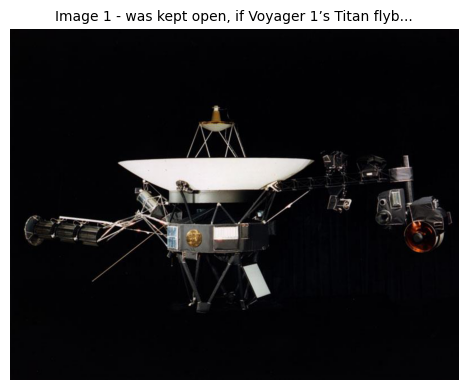

  Displayed image 1 (caption: was kept open, if Voyager 1’s Titan flyby was successful, to retarget Voyager 2 ...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 2] ID: 2
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why was this photograph considered a major engineering milestone even though the spacecraft was still relatively close to Earth by solar system standards?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.3924 sec
  Image: 0.2111 sec
  Total: 2.254700900055468 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6462
  Avg Image:   0.54
  Avg Overall: 0.5931

📝

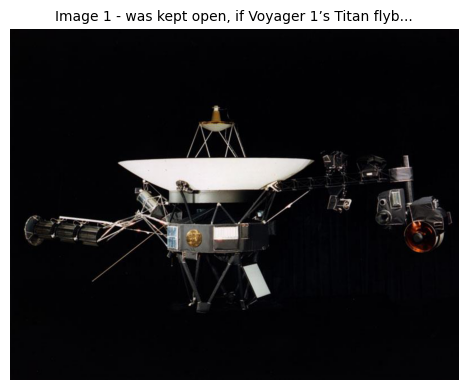

  Displayed image 1 (caption: was kept open, if Voyager 1’s Titan flyby was successful, to retarget Voyager 2 ...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 3] ID: 3
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: What specific visual features in this montage support the claims of active volcanoes on Io and a possible subsurface ocean on Europa?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.3201 sec
  Image: 0.1849 sec
  Total: 1.7732063999865204 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6303
  Avg Image:   0.4364
  Avg Overall: 0.5334

📝 Formatted Query: 

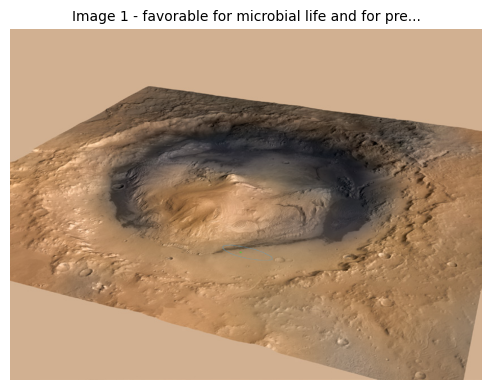

  Displayed image 1 (caption: favorable for microbial life and for preserving clues in the rocks about possibl...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 4] ID: 4
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why did the mission team deliberately wait until just before permanently shutting down the cameras to capture this image, and what deeper message does it convey?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.3461 sec
  Image: 0.1886 sec
  Total: 2.08614479994867 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.5503
  Avg Image:   0.4178
  Avg Overall: 0

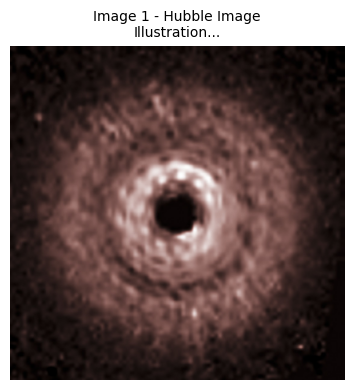

  Displayed image 1 (caption: Hubble Image
Illustration...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 5] ID: 5
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why was 1970s analog technology deliberately chosen for a message that might be found tens of thousands of years in the future?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.3906 sec
  Image: 0.159 sec
  Total: 2.0462271999567747 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.5184
  Avg Image:   0.4586
  Avg Overall: 0.4885

📝 Formatted Query: Why was 1970s analog technology deliberately chosen for a mess

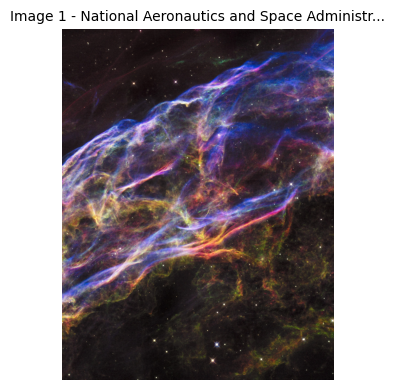

  Displayed image 1 (caption: National Aeronautics and Space Administration...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 6] ID: 6
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: What scientific trade-off led to Voyager 1's flyby permanently sacrificing all future planetary encounters while Voyager 2 was allowed to continue?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.408 sec
  Image: 0.176 sec
  Total: 1.7603922000853345 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6453
  Avg Image:   0.5982
  Avg Overall: 0.6218

📝 Formatted Query: What scientific trade-o

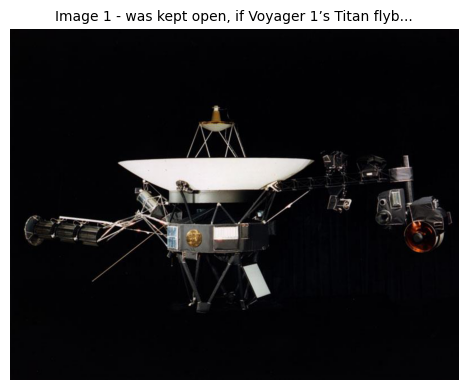

  Displayed image 1 (caption: was kept open, if Voyager 1’s Titan flyby was successful, to retarget Voyager 2 ...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 7] ID: 7
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why is it counterintuitive that Voyager 2 discovered more new moons at these distant ice giants than at Jupiter and Saturn combined, despite spending far less time observing them?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.4085 sec
  Image: 0.232 sec
  Total: 2.045664899982512 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6901
  Avg Image:   0.565

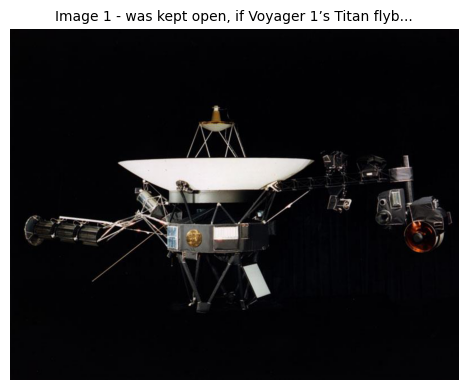

  Displayed image 1 (caption: was kept open, if Voyager 1’s Titan flyby was successful, to retarget Voyager 2 ...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 8] ID: 8
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: How does the visible design explain why both spacecraft could still be operating after 45+ years when most missions are planned for only a few years?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.4194 sec
  Image: 0.1872 sec
  Total: 2.239528000005521 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6096
  Avg Image:   0.5261
  Avg Overall: 0.5678

📝 Fo

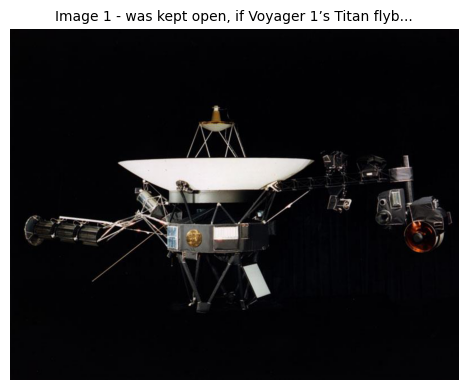

  Displayed image 1 (caption: was kept open, if Voyager 1’s Titan flyby was successful, to retarget Voyager 2 ...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 9] ID: 9
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Reconstruct the full ancient river system story and explain why this image alone was not sufficient to prove past habitability.
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.3462 sec
  Image: 0.176 sec
  Total: 1.9630271999631077 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6227
  Avg Image:   0.4668
  Avg Overall: 0.5447

📝 Formatted Query: Reconst

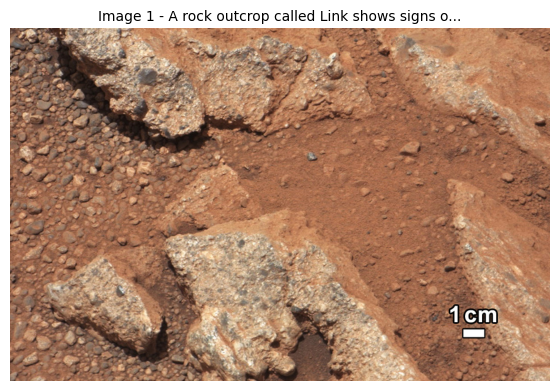

  Displayed image 1 (caption: A rock outcrop called Link shows signs of being formed by the deposition 
of wat...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 10] ID: 10
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why was the 20 km landing precision improvement not just an engineering achievement but a fundamental prerequisite for the entire scientific mission?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.3304 sec
  Image: 0.157 sec
  Total: 1.856019499944523 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6059
  Avg Image:   0.4675
  Avg Overall: 0.5367

📝 F

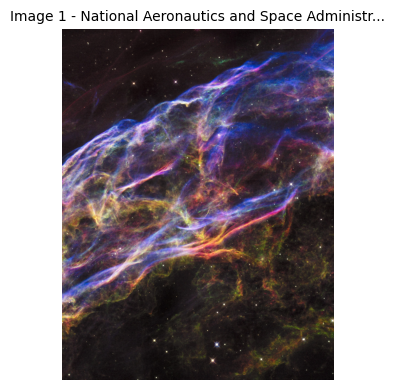

  Displayed image 1 (caption: National Aeronautics and Space Administration...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 11] ID: 11
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: How was this image technically assembled, and what does it reveal about the rover's mobility and self-diagnostic capabilities?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.3343 sec
  Image: 0.1684 sec
  Total: 1.932073300005868 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6761
  Avg Image:   0.5401
  Avg Overall: 0.6081

📝 Formatted Query: How was this image technically assembled,

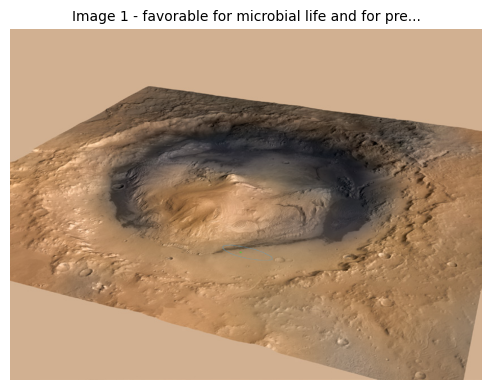

  Displayed image 1 (caption: favorable for microbial life and for preserving clues in the rocks about possibl...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 12] ID: 12
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: How does the powdered interior sample, combined with the 4.2 billion year age, create a paradox about geological preservation on Mars?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.3745 sec
  Image: 0.1734 sec
  Total: 2.0142667000181973 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6023
  Avg Image:   0.5314
  Avg Overall: 0.5668

📝 Formatted Quer

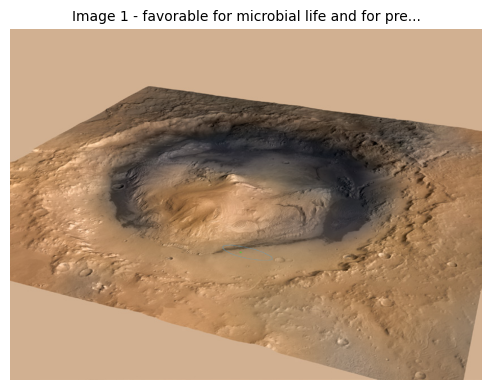

  Displayed image 1 (caption: favorable for microbial life and for preserving clues in the rocks about possibl...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 13] ID: 13
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why was the documented decline in radioisotope power from 110W to 100W over two years actually a positive indicator for long-term mission success?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.3806 sec
  Image: 0.1848 sec
  Total: 2.1045234999619424 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6172
  Avg Image:   0.4324
  Avg Overall: 0.5248

📝 Fo

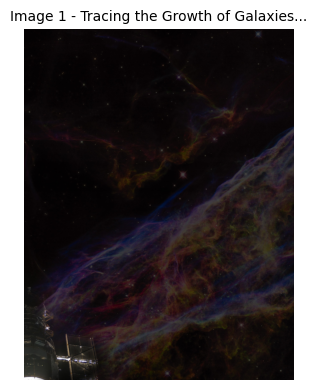

  Displayed image 1 (caption: Tracing the Growth of Galaxies...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 14] ID: 14
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why does the document argue that visual imaging alone could never have proven past habitability, and what hierarchical chain of instruments was required?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.3715 sec
  Image: 0.2111 sec
  Total: 2.0963959000073373 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6038
  Avg Image:   0.5001
  Avg Overall: 0.5519

📝 Formatted Query: Why does the document argue 

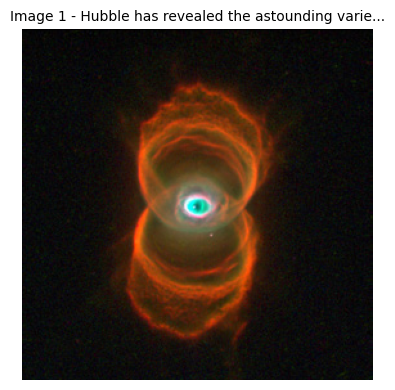

  Displayed image 1 (caption: Hubble has revealed the astounding variety and amazing complexity of planetary n...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 15] ID: 15
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why was Gale Crater chosen over dozens of other sites, and how did the payload directly address the habitability question?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.3168 sec
  Image: 0.2017 sec
  Total: 2.015970299951732 sec

📊 Cosine Similarity (1 - distance):
  Avg Text:    0.6698
  Avg Image:   0.5377
  Avg Overall: 0.6037

📝 Formatted Query: Why was Ga

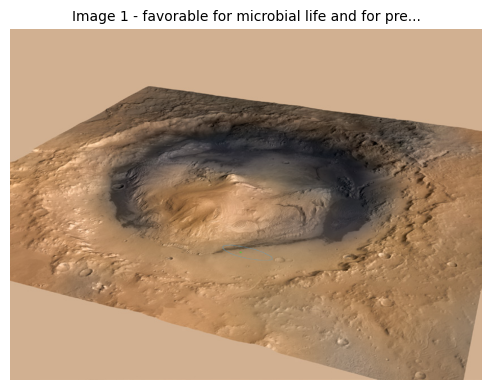

  Displayed image 1 (caption: favorable for microbial life and for preserving clues in the rocks about possibl...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------




In [36]:
display_formatted_results(retrieval_output, formatter)

# **# M5: Top-k Accuracy**

In [41]:
def compute_m5_topk_accuracy_structural(retrieval_output, test_questions, k=3):
    """
    TRUE M5 for your dataset.

    Checks whether the retrieved Top-k chunks come from
    the page specified in TEST_QUESTIONS.required_context.
    """

    # Build GT mapping
    gt_pages = {
        q["id"]: q["required_context"]["pages"][0]
        for q in test_questions
    }

    matches = 0
    total = 0

    for item in retrieval_output:

        qid = item["id"]
        if qid not in gt_pages:
            continue

        correct_page = gt_pages[qid]

        metas = item["result"]["text_results"]["metadatas"][0][:k]

        retrieved_pages = [
            m.get("page_num") or m.get("page")
            for m in metas
        ]

        if correct_page in retrieved_pages:
            matches += 1

        total += 1

    score = (matches / total) * 100 if total else 0

    print(f"\nM5 Top-{k} Accuracy (Structural): {score:.2f}%")
    print(f"Matches: {matches}/{total}")

    return score

In [42]:
compute_m5_topk_accuracy_structural(retrieval_output, TEST_QUESTIONS, k=3)


M5 Top-3 Accuracy (Structural): 80.00%
Matches: 12/15


80.0

# # **M6, M7, M8 (ROUGE Evaluation)**

In [48]:
from rouge_score import rouge_scorer

def compute_m6_m7_m8_rouge(retrieval_output, test_questions):
    """
    Computes:
        M6 = ROUGE-1  (Content Coverage)
        M7 = ROUGE-2  (Phrase Similarity)
        M8 = ROUGE-L  (Sentence Structure)

    Ground Truth is taken from the page specified in:
        TEST_QUESTIONS.required_context.pages

    Prediction is:
        Top-1 retrieved chunk from retriever.
    """

    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

    r1_scores, r2_scores, rl_scores = [], [], []

    for item in retrieval_output:

        qid = item["id"]

        # -----------------------------
        # Find expected page from TEST_QUESTIONS
        # -----------------------------
        expected_page = None
        for q in test_questions:
            if q["id"] == qid:
                expected_page = q["required_context"]["pages"][0]
                break

        if expected_page is None:
            continue

        # Determine which document this belongs to
        expected_source_keyword = "voyager" if qid <= 8 else "mars"

        docs = item["result"]["text_results"]["documents"][0]
        metas = item["result"]["text_results"]["metadatas"][0]

        # -----------------------------
        # Prediction = Top retrieved chunk
        # -----------------------------
        pred_text = docs[0]

        # -----------------------------
        # Ground Truth = chunk from correct page
        # -----------------------------
        gt_text = ""

        for d, m in zip(docs, metas):
            src = m.get("source", "").lower()
            pg  = m.get("page_num") or m.get("page")

            if expected_source_keyword in src and pg == expected_page:
                gt_text = d
                break

        # fallback (if retriever missed correct chunk)
        if gt_text == "":
            gt_text = docs[0]

        # -----------------------------
        # Compute ROUGE
        # -----------------------------
        scores = scorer.score(gt_text, pred_text)

        r1_scores.append(scores["rouge1"].fmeasure)
        r2_scores.append(scores["rouge2"].fmeasure)
        rl_scores.append(scores["rougeL"].fmeasure)

    # -----------------------------
    # Final Averages
    # -----------------------------
    M6 = sum(r1_scores) / len(r1_scores) if r1_scores else 0
    M7 = sum(r2_scores) / len(r2_scores) if r2_scores else 0
    M8 = sum(rl_scores) / len(rl_scores) if rl_scores else 0

    print("\n===== ANSWER QUALITY METRICS =====")
    print(f"M6 ROUGE-1 (Content Coverage):     {M6:.4f}")
    print(f"M7 ROUGE-2 (Phrase Similarity):    {M7:.4f}")
    print(f"M8 ROUGE-L (Sentence Structure):   {M8:.4f}")

    return M6, M7, M8

In [49]:
compute_m6_m7_m8_rouge(retrieval_output, TEST_QUESTIONS)


===== ANSWER QUALITY METRICS =====
M6 ROUGE-1 (Content Coverage):     0.8696
M7 ROUGE-2 (Phrase Similarity):    0.8126
M8 ROUGE-L (Sentence Structure):   0.8279


(0.8695714956236489, 0.8125938990768388, 0.8279109843777069)